# SpeedTuning — Full Pipeline Demo

Follows the plan in `doc/Task for tuning.md`:

1. Artificial `modulated_mask` (simulating `BinaryModulation.tuned_mask`)
2. `find_preferred_conditions` → per-neuron `trial_mask`
3. `SpeedTuning` on preferred-condition trials
4. Plot: tuning curves by monotonicity (with spont baseline)
5. Plot: modulated & tuned neuron counts
6. Plot: grid map (modulated mask + p-value + coloured ρ)

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

data = load_data("data")
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
# trial_blank_dict = {stim: extract_blank_trials(data, stimulus=stim) for stim in STIMULI[:-1]}
mode = 'equal_size'

## 0. Artificial modulated_mask + preferred-condition trial_mask

Simulate `BinaryModulation.tuned_mask` and compute per-neuron preferred conditions.

In [2]:
# Artificial masks — full neurons, no still-exclusion (keeps form to show calling logic)
modulated_mask = {}
pref_trial_masks = {}
still_trial_masks = {}

for stim_label, stim_name in zip(SHORT_STIM, STIMULI):
    td = trial_data_dict[stim_name]
    n_trials = td.responses.shape[1]
    if stim_name == 'spontaneous':  # 并集：其他三个stim的modulated neurons
        modulated_mask[stim_label] = (modulated_mask['dg'] |
                                      modulated_mask['sg'] |
                                      modulated_mask['ns'])
        pref_trial_masks[stim_label] = None
    else:
        modulated_mask[stim_label] = np.ones(N_CELLS, dtype=bool)
        preferred_labels, pref_trial_mask, _ = find_preferred_conditions(td, top_frac=1)
        pref_trial_masks[stim_label] = pref_trial_mask
    still_trial_masks[stim_label] = np.zeros(n_trials, dtype=bool)

for lbl in SHORT_STIM:
    n_still = still_trial_masks[lbl].sum()
    n_mod = modulated_mask[lbl].sum()
    print(f"{lbl}: {n_mod} modulated / {N_CELLS} total, {n_still} still excluded")

dg: 47 modulated / 47 total, 0 still excluded
sg: 47 modulated / 47 total, 0 still excluded
ns: 47 modulated / 47 total, 0 still excluded
spont: 47 modulated / 47 total, 0 still excluded


## 1. Run SpeedTuning — all stimuli in a dict

Pattern mirrors `Session A.ipynb`: dict comprehension → `run()`.

In [10]:

tunings = {label: SpeedTuning(trial_data_dict[stim], mode=mode,
                              neuron_mask=modulated_mask[label],
                              pref_trial_mask=pref_trial_masks[label],
                              still_trial_mask=still_trial_masks[label])
           for (label, stim) in zip(SHORT_STIM, STIMULI)}
for stim in SHORT_STIM:
    tunings[stim].run()


## 2. Tuning curves by monotonicity (with spontaneous baseline)

Dashed lines = spontaneous activity of the same-category cells.

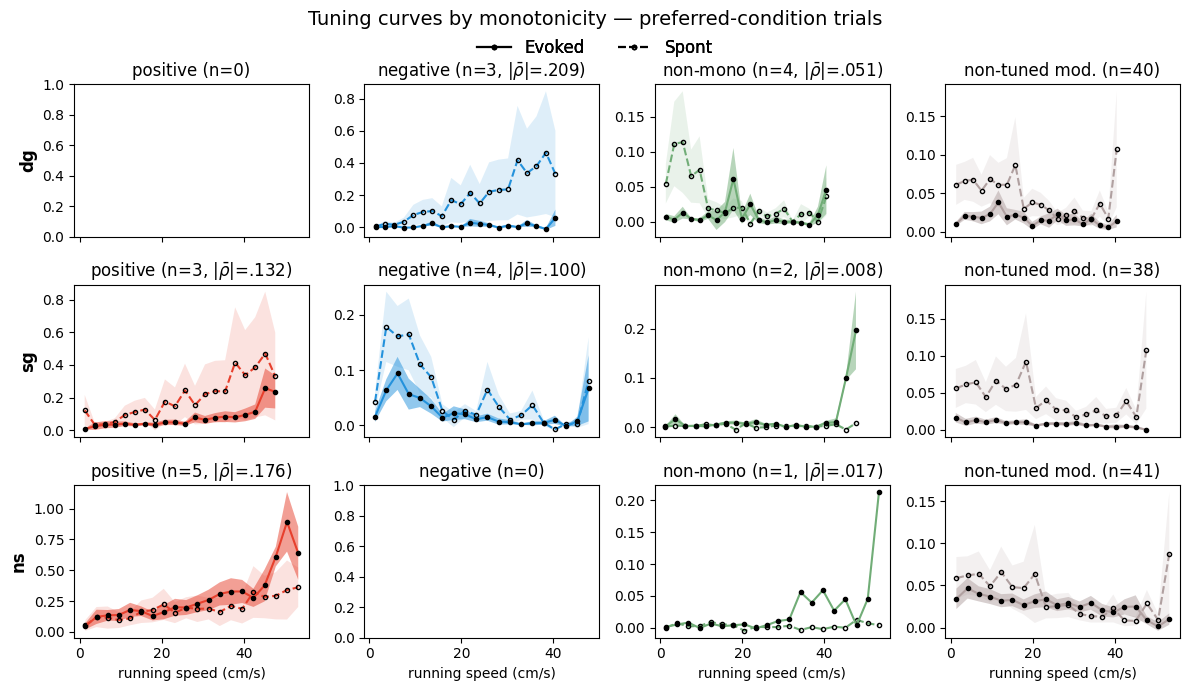

In [11]:
stim_labels = ['dg', 'sg', 'ns']

fig, axes = plt.subplots(3, 4, figsize=(12, 7), sharex='col')

for row, stim in enumerate(stim_labels):
    tunings[stim].plot_tuning_by_monotonicity(
        axes=axes[row], spontaneous=tunings['spont'],
        modulated_mask=modulated_mask[stim])
    axes[row, 0].set_ylabel(stim, fontsize=12, fontweight='bold')
    for ax in axes[row]:
        ax.set_xlabel(None)

for col in range(4):
    axes[2, col].set_xlabel('running speed (cm/s)')

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.suptitle('Tuning curves by monotonicity — preferred-condition trials', fontsize=14)
plt.show()

## 3. Stacked bar: tuned neuron counts

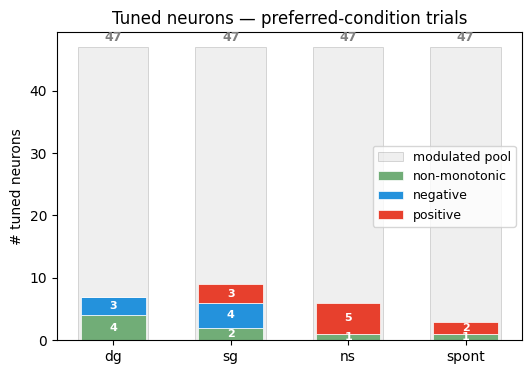

In [21]:
# All cells on preferred condition
ax = plot_monotonicity_stacked_bar(tunings, modulated_mask=modulated_mask, figsize=(6, 4))
ax.set_title('Tuned neurons — preferred-condition trials')
plt.show()

## 4. Grid map: modulated mask + p-value + coloured ρ

Each row = one cell, each column = one stimulus.
- Light blue background: running-modulated (`BinaryModulation.tuned_mask`)
- Coloured ρ text: monotonicity category from `SpeedTuning`
- Stars: significance level of tuning variance

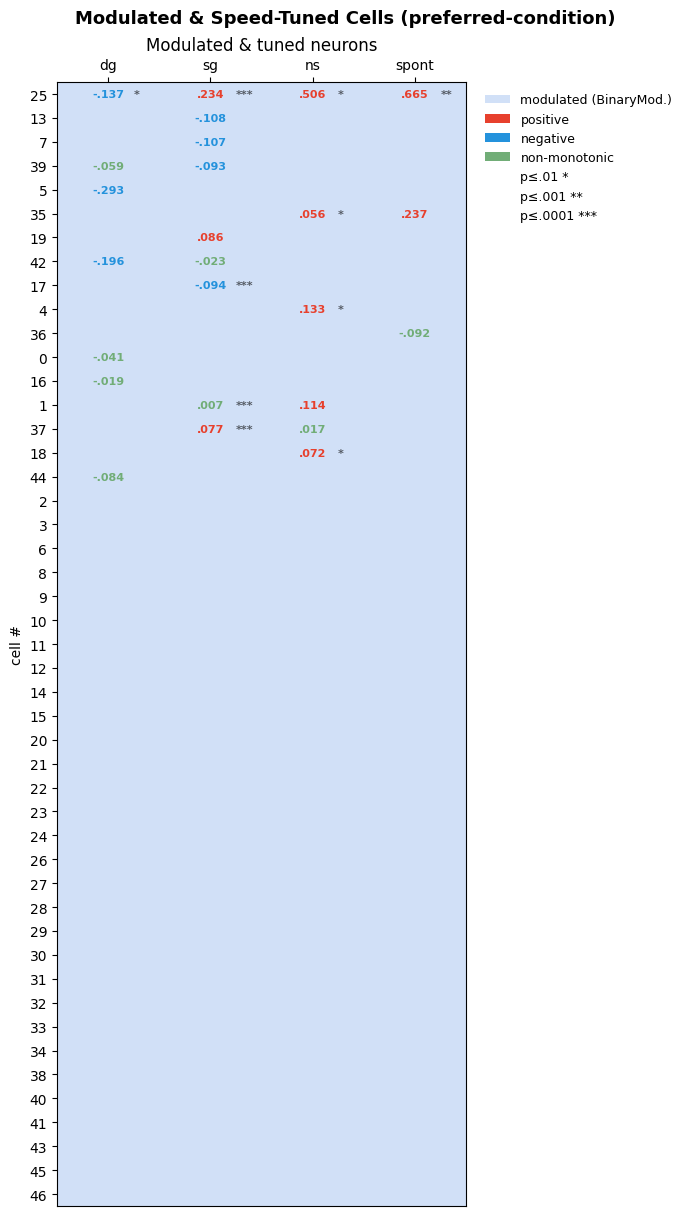

In [13]:
fig = plot_modulated_tuned_grid(tunings, modulated_mask=modulated_mask,
                                 figsize=(7, 12))
fig.suptitle('Modulated & Speed-Tuned Cells (preferred-condition)',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

## 5. Pairwise ρ scatter

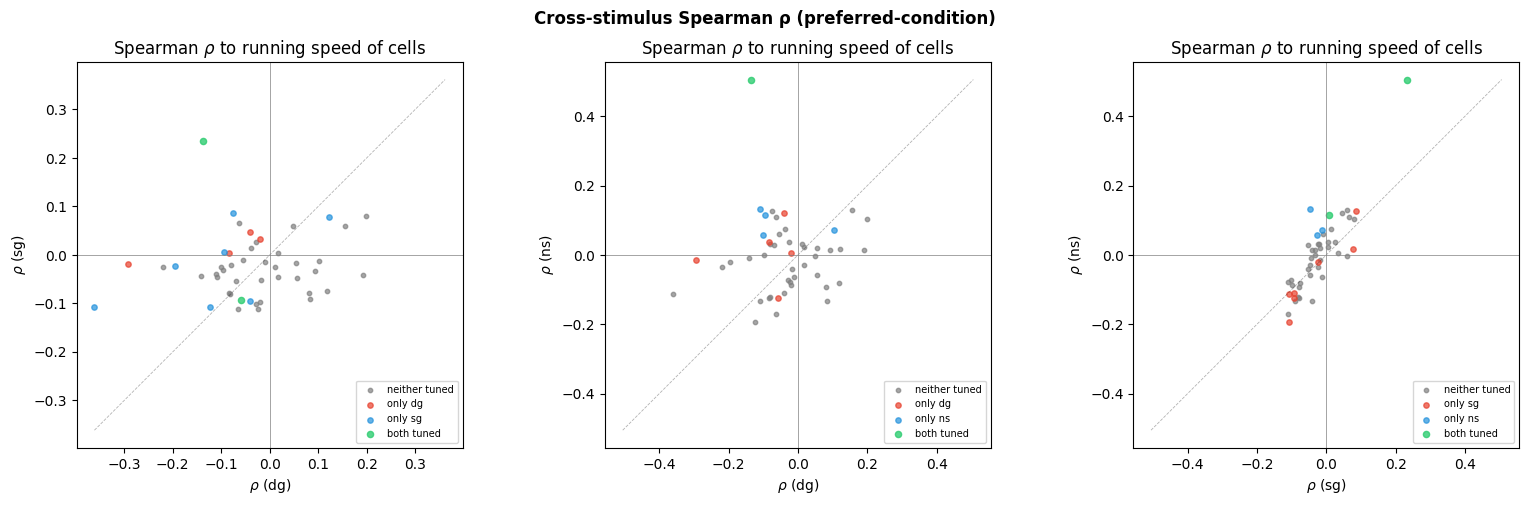

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('dg', 'sg'), ('dg', 'ns'), ('sg', 'ns')]
for ax, (a, b) in zip(axes, pairs):
    plot_rho_pairwise_scatter(tunings[a], tunings[b], a, b, ax=ax)

plt.suptitle('Cross-stimulus Spearman ρ (preferred-condition)', fontweight='bold')
plt.tight_layout()
plt.show()